# Homework 2 — Part 1(a): Generate the problem

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 1, Problem 1(a)(i–v).

We will eventually minimize
$$f(x)=\frac12 x^TQx+b^Tx,\qquad x\in\mathbb{R}^{100}.$$
This part generates the fixed problem parameters $Q$ and $b$. The vector $x$ will be the variable we optimize later.

In [1]:
import numpy as np

# Fixed seed for reproducible results (our implementation choice).
rng = np.random.default_rng(650)

# 1(a)(i): dimension of the problem.
n = 100

# 1(a)(ii): independent standard normal entries, mean 0 and variance 1.
B = rng.standard_normal((n, n))

# 1(a)(iii): exponentiate standard normals, then put them on the diagonal.
D = np.diag(np.exp(rng.standard_normal(n)))

# 1(a)(iv): @ is matrix multiplication; .T is the transpose.
Q = B @ B.T + D

# 1(a)(v): multiplying by 10 gives variance 10**2 = 100.
b = 10 * rng.standard_normal(n)

**How the code corresponds to the assignment**

- `n = 100`: each candidate $x$ has 100 coordinates; $Q$, $B$, and $D$ are $100\times100$ matrices.
- `rng.standard_normal((n, n))` implements the assignment's `randn(100,100)` distribution.
- `np.exp(...)` transforms standard normal samples into standard log-normal samples. These are positive. `np.diag(...)` puts them on the diagonal, with zeros elsewhere.
- `B @ B.T` implements $BB^T$. NumPy's `*` would multiply entries individually, which is a different operation.
- `10 * rng.standard_normal(n)` gives each entry of $b$ mean zero and variance 100: $\operatorname{Var}(10Z)=10^2\operatorname{Var}(Z)$.

**Implementation choices:** The assignment does not specify a seed; `650` lets us reproduce the same instance when rerunning this cell. We represent $b$ with NumPy shape `(100,)`, rather than `(100, 1)`, and will use that same vector convention for $x$.

**Why this construction is useful (our derivation):** For any nonzero vector $v$,
$$v^TQv=\|B^Tv\|^2+\sum_{i=1}^{100}D_{ii}v_i^2>0.$$
The first term is nonnegative, and the second is positive because every $D_{ii}>0$. Thus $Q$ is symmetric positive definite. This will matter when we solve the optimization problem in part 1(b).

## Part 1(b): Compute the optimal solution

**Sources:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(b), asks us to use the first-order optimality condition. [Lecture_2_Optimality.pdf](../slides/Lecture_2_Optimality.pdf), slide 10/17 (PDF page 11), “Unconstrained quadratic optimization,” states that when $Q\succ0$, the unique global minimizer solves $Qx^\star=-b$.

**Derivation for our objective:**

The gradient collects the first partial derivatives. Since $Q=Q^T$,
$$\nabla f(x)=\frac12(Q+Q^T)x+b=Qx+b.$$
The factor $1/2$ in the objective cancels the factor of two from differentiating the symmetric quadratic term.

At an unconstrained differentiable minimum, the first-order condition requires the gradient to be zero:
$$\nabla f(x^\star)=0\quad\Longrightarrow\quad Qx^\star+b=0\quad\Longrightarrow\quad Qx^\star=-b.$$
Thus, mathematically, $x^\star=-Q^{-1}b$.

A zero gradient alone does not guarantee a minimum for every function. Here, the Hessian is $\nabla^2 f(x)=Q\succ0$ by part 1(a), so this stationary point is the **unique global minimizer**, as stated on the lecture slide.

**Implementation choice:** `np.linalg.solve(Q, -b)` solves the linear system directly, avoiding the extra work and numerical error of explicitly constructing `np.linalg.inv(Q)`. We call the result `x_star` to match $x^\star$.

In [2]:
# Solve the first-order optimality equation Q @ x_star = -b.
x_star = np.linalg.solve(Q, -b)

# Check how close the computed gradient is to zero.
gradient_at_x_star = Q @ x_star + b
print("Gradient norm at x_star:", np.linalg.norm(gradient_at_x_star))

Gradient norm at x_star: 5.997081613800755e-13


**Reading the check:** `Q @ x_star + b` is $\nabla f(x^\star)$. `np.linalg.norm(...)` computes its Euclidean length, so the printed value should be close to zero. A tiny nonzero result is expected from floating-point arithmetic. This is a numerical check of the optimality equation; the positive-definiteness argument above establishes why its solution is the unique minimum.

## Part 1(c): Gradient descent with four step-size rules

**Assignment:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(c)(i–iv).

**Common update:** [Lecture_5_Descent.pdf](../slides/Lecture_5_Descent.pdf), slide 3/15 (PDF page 4), gives $x_{k+1}=x_k+\alpha_k d_k$ and the steepest descent direction $d_k=-\nabla f(x_k)$. Using the gradient from 1(b), all four methods implement
$$g_k=Qx_k+b,\qquad x_{k+1}=x_k-\alpha_k g_k.$$
The negative gradient gives a downhill direction; the step size determines how far we move.

Each function below copies `x0` so it does not change the caller's starting vector, and returns **only the final vector** `x`. The methods do not need `x_star`; that reference solution is used only to evaluate their results.

In [3]:
def f(x, Q, b):
    return 0.5 * x @ Q @ x + b @ x


def grad_f(x, Q, b):
    return Q @ x + b

### (i) Exact line search

**Source:** Lecture 5, slide 6/15 (PDF page 7), “Exact line search on a quadratic.”

At the current point, choose the step that minimizes the objective along $-g$:
$$f(x-\alpha g)=f(x)-\alpha g^Tg+\frac{\alpha^2}{2}g^TQg.$$
Differentiating this expression with respect to $\alpha$ and setting it to zero gives
$$\alpha=\frac{g^Tg}{g^TQg}.$$
This is the lecture formula with $d=-g$; the minus signs cancel in both quadratic expressions. “Exact” means optimal **along this direction**, not that one step necessarily reaches $x^\star$. For nonzero $g$, positive definiteness guarantees $g^TQg>0$.

In [4]:
def gd_exact(Q, b, x0, num_iters):
    x = np.array(x0, dtype=float, copy=True)

    for _ in range(num_iters):
        g = grad_f(x, Q, b)
        if not np.any(g):  # Already stationary: avoid 0 / 0.
            break
        step = (g @ g) / (g @ Q @ g)
        x = x - step * g

    return x

### (ii) Armijo backtracking

**Source:** Lecture 5, slide 7/15 (PDF page 8), the **BACKTRACK** formula, which includes the trial step in the sufficient-decrease condition.

Start each iteration with $\bar\alpha$. Shrink the trial step by $\beta$ until
$$f(x-\alpha g)\leq f(x)-\sigma\alpha\|g\|^2.$$
This is the lecture's backtracking inequality with $d=-g$, rearranged. The objective must decrease by at least a fraction $\sigma$ of the decrease predicted by the linear approximation.

**Our parameter choices:** $\bar\alpha=1$, $\beta=0.5$, and $\sigma=10^{-4}$. The assignment does not prescribe these values. Each rejected trial is halved, and the first acceptable trial is used.

In [5]:
def gd_armijo(Q, b, x0, num_iters,
              alpha_bar=1.0, beta=0.5, sigma=1e-4):
    if alpha_bar <= 0 or not 0 < beta < 1 or not 0 < sigma < 1:
        raise ValueError("Require alpha_bar > 0 and 0 < beta, sigma < 1.")

    x = np.array(x0, dtype=float, copy=True)

    for _ in range(num_iters):
        g = grad_f(x, Q, b)
        if not np.any(g):
            break
        step = alpha_bar
        current_value = f(x, Q, b)

        while f(x - step * g, Q, b) > current_value - sigma * step * (g @ g):
            step *= beta

        x = x - step * g

    return x

### (iii) Diminishing step size

**Sources:** Homework 2, 1(c)(iii), specifies $\alpha_r=\alpha/r$. Lecture 5, slide 4/15 (PDF page 5), describes diminishing steps that approach zero while their sum diverges.

We number updates $r=1,\ldots,\texttt{num_iters}$ so that we never divide by zero. The steps are $\alpha,\alpha/2,\alpha/3,\ldots$; the first step moves from $x_0$ to $x_1$.

**Our coefficient choice for the example:** $\alpha=1/L$. The homework leaves this coefficient unspecified. This choice starts at the constant method's step size and then shrinks. It is conservative and may make slow progress over a finite run.

In [6]:
def gd_diminishing(Q, b, x0, num_iters, alpha):
    x = np.array(x0, dtype=float, copy=True)

    for r in range(1, num_iters + 1):
        g = grad_f(x, Q, b)
        step = alpha / r
        x = x - step * g

    return x

### (iv) Constant step size $1/L$

**Sources:** Homework 2, 1(c)(iv), requires $1/L$. [Lecture_6_Convergence.pdf](../slides/Lecture_6_Convergence.pdf), slide 3/9 (PDF page 4), gives the descent bound for this step. Slide 9/9 (PDF page 10) relates the Hessian bound to the gradient Lipschitz constant.

**Derivation for this quadratic:** Since $\nabla f(x)-\nabla f(y)=Q(x-y)$,
$$\|\nabla f(x)-\nabla f(y)\|_2\leq\|Q\|_2\|x-y\|_2.$$
For symmetric positive definite $Q$, $\|Q\|_2=\lambda_{\max}(Q)$, so we use $L=\lambda_{\max}(Q)$.

`np.linalg.eigvalsh(Q)` computes the eigenvalues of a real symmetric matrix; its largest eigenvalue gives $L$. Compute the step once and reuse it in every iteration.

In [7]:
def gd_constant(Q, b, x0, num_iters):
    x = np.array(x0, dtype=float, copy=True)
    L = np.linalg.eigvalsh(Q).max()
    step = 1.0 / L

    for _ in range(num_iters):
        g = grad_f(x, Q, b)
        x = x - step * g

    return x

### Numerical check on our current instance

Run the four implementations from $x_0=0$ for 1000 updates, using the starting point and iteration count specified in Problem 1(f). This is a check on the single instance from 1(a); the full six-method log-relative accuracy comparison and five-realization averages will be added in their respective parts.

We print $\|Qx+b\|_2$ (the gradient norm) and $\|x-x^\star\|_2/\|x_0-x^\star\|_2$ (relative distance to the reference solution). Smaller values mean closer to stationarity or to the reference solution, respectively.

In [8]:
x0 = np.zeros(n)
num_iters = 1000
L = np.linalg.eigvalsh(Q).max()

x_exact = gd_exact(Q, b, x0, num_iters)
x_armijo = gd_armijo(Q, b, x0, num_iters)
x_diminishing = gd_diminishing(Q, b, x0, num_iters, alpha=1.0 / L)
x_constant = gd_constant(Q, b, x0, num_iters)

print(f"L = {L:.6f}; 1/L = {1 / L:.6e}")
print(f"{'Method':<20} {'Relative error':>16} {'Gradient norm':>16}")
for name, x_result in [
    ("Exact line search", x_exact),
    ("Armijo", x_armijo),
    ("Diminishing", x_diminishing),
    ("Constant 1/L", x_constant),
]:
    rel_error = np.linalg.norm(x_result - x_star) / np.linalg.norm(x0 - x_star)
    grad_norm = np.linalg.norm(grad_f(x_result, Q, b))
    print(f"{name:<20} {rel_error:>16.6e} {grad_norm:>16.6e}")

L = 386.914033; 1/L = 2.584553e-03
Method                 Relative error    Gradient norm
Exact line search        1.493652e-03     4.278253e-02
Armijo                   9.714499e-04     5.799149e-02
Diminishing              9.634647e-01     5.235364e+01
Constant 1/L             4.004516e-02     9.256808e-01


## Part 1(d): Nesterov's accelerated gradient method

**Assignment:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(d), asks for the accelerated gradient method discussed in class.

**Sources and version:** The available [Lecture 7 slides](../slides/Lecture_7_Descent_Strongly%20convex.pdf), slide 1/5 (PDF page 2), define strong convexity, smoothness, and $\kappa=L/\mu$, but do not show the accelerated update. We use the **smooth, strongly convex** Nesterov method in Bubeck, *Convex Optimization: Algorithms and Complexity*, [Section 3.7.1](../textbook%20and%20materials/1405.4980v2.pdf), printed page 290 (PDF page 63). This supplies a local reference for the implementation; it does not independently confirm which variant was presented in class.

For our quadratic, the Hessian is $Q$, so
$$\mu=\lambda_{\min}(Q),\qquad L=\lambda_{\max}(Q),\qquad\kappa=\frac{L}{\mu}.$$
Here $\mu>0$ measures the smallest curvature and $L$ the largest curvature. Define the momentum coefficient
$$\gamma=\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}.$$
This coefficient is prescribed by the referenced method, rather than selected by trial and error. The text calls the strong convexity constant $\alpha$ and the smoothness constant $\beta$; we use $\mu$ and $L$ to match our course notation.

Initialize $x_0=y_0$ at the starting vector and repeat
$$y_{r+1}=x_r-\frac{1}{L}(Qx_r+b),$$
$$x_{r+1}=y_{r+1}+\gamma(y_{r+1}-y_r).$$
These are the text's equations with indexing shifted to start at zero.

**How the two lines work:**

1. `y_next` takes a gradient step from the current evaluation point `x` with step size $1/L$.
2. `y_next - y` measures the displacement between successive gradient-step results. Adding a fraction $\gamma$ of this displacement extrapolates to `x_next`, the point where the next gradient will be evaluated.
3. We keep both sequences because the next momentum update needs the old `y`. The function returns the final `y`, the sequence bounded in the reference's Theorem 3.18; the caller names this final estimate `x_nesterov`.

The first gradient step matches ordinary gradient descent because both sequences start at the same point. Subsequent gradient evaluations use the extrapolated points. The function requires no knowledge of `x_star`.

In [9]:
def nesterov(Q, b, x0, num_iters):
    eigvals = np.linalg.eigvalsh(Q)
    mu = eigvals.min()
    L = eigvals.max()
    kappa = L / mu
    gamma = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)

    x = np.array(x0, dtype=float, copy=True)
    y = x.copy()

    for _ in range(num_iters):
        # Gradient step at the current evaluation point.
        y_next = x - grad_f(x, Q, b) / L

        # Extrapolate using the displacement from the previous y.
        x_next = y_next + gamma * (y_next - y)

        y = y_next
        x = x_next

    return y

### Numerical check on the current instance

Use the same $x_0=0$ and 1000 updates as in our 1(c) check. Compare against constant-step gradient descent on the same $Q,b$. We report numerical outputs only, as planned for Problem 1.

Theorem 3.18 in the cited text bounds the **objective gap** by a term proportional to $\exp(-r/\sqrt{\kappa})$. This explains why acceleration can help when $\kappa$ is large. The relative distances below are a numerical comparison, not a direct measurement of that objective-gap bound.

In [10]:
x_nesterov = nesterov(Q, b, x0, num_iters)

eigvals = np.linalg.eigvalsh(Q)
mu = eigvals.min()
L = eigvals.max()
kappa = L / mu
gamma = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)

print(f"mu = {mu:.6f}; L = {L:.6f}")
print(f"kappa = {kappa:.6f}; momentum gamma = {gamma:.6f}")
print(f"{'Method':<20} {'Relative error':>16} {'Gradient norm':>16}")
for name, x_result in [
    ("Constant 1/L", x_constant),
    ("Nesterov", x_nesterov),
]:
    rel_error = np.linalg.norm(x_result - x_star) / np.linalg.norm(x0 - x_star)
    grad_norm = np.linalg.norm(grad_f(x_result, Q, b))
    print(f"{name:<20} {rel_error:>16.6e} {grad_norm:>16.6e}")

mu = 1.123169; L = 386.914033
kappa = 344.484378; momentum gamma = 0.897752
Method                 Relative error    Gradient norm
Constant 1/L             4.004516e-02     9.256808e-01
Nesterov                 3.206003e-15     4.550095e-13


## Part 1(e): Newton's method

**Assignment:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(e).

**Sources:** [Lecture_5_Descent.pdf](../slides/Lecture_5_Descent.pdf), slide 3/15 (PDF page 4), gives the Newton direction $d_r=-[\nabla^2 f(x_r)]^{-1}\nabla f(x_r)$. Boyd and Vandenberghe, *Convex Optimization*, [Section 9.5.1](../textbook%20and%20materials/bv_cvxbook.pdf), printed page 484 (PDF page 498), explains it as the minimizer of the second-order model and states that a full Newton step exactly minimizes a positive definite quadratic.

**Applying the formula to our objective:**
$$\nabla f(x)=Qx+b,\qquad\nabla^2 f(x)=Q.$$
The Hessian collects second derivatives and describes curvature. Newton's method uses this curvature to transform the gradient into a step. Solve
$$Qd_r=-(Qx_r+b),$$
then take the full step
$$x_{r+1}=x_r+d_r.$$

**Why a full step works here (our algebra):**
$$x_{r+1}=x_r-Q^{-1}(Qx_r+b)=x_r-x_r-Q^{-1}b=-Q^{-1}b=x^\star.$$
Thus, in exact arithmetic, one step reaches the unique minimizer from any starting point. Newton's local quadratic model is the objective itself in this problem. This one-step property does not hold for general nonquadratic objectives.

**Implementation choices:** Use a full step (step size 1) and `np.linalg.solve(Q, -g)` to find the direction without forming an inverse. Keep the same `num_iters` interface and return only the final vector, as in the other methods. The function never reads `x_star`. We retain all requested updates for the later 1000-iteration comparison; after the first step they mainly reflect floating-point roundoff.

In [11]:
def newton(Q, b, x0, num_iters):
    x = np.array(x0, dtype=float, copy=True)

    for _ in range(num_iters):
        g = grad_f(x, Q, b)
        d = np.linalg.solve(Q, -g)  # Hessian Q times direction d equals -g.
        x = x + d                  # Full Newton step: step size is 1.

    return x

### Numerical check: one step and 1000 steps

Use the same zero starting point and current problem instance. `x_newton_1` checks the one-step property, while `x_newton` stores the result after 1000 updates for later comparison.

Starting from zero, the first direction is computed by the same linear solve used for `x_star` in 1(b), so the reported relative error can be exactly zero. The gradient norm can still be a tiny nonzero number because of floating-point arithmetic. Further updates need not improve the reported distance monotonically once it is at numerical precision.

Each Newton iteration solves a linear system, so equal iteration counts across methods do not imply equal computational work.

In [12]:
x_newton_1 = newton(Q, b, x0, 1)
x_newton = newton(Q, b, x0, num_iters)

print(f"{'Method':<22} {'Relative error':>16} {'Gradient norm':>16}")
for name, x_result in [
    ("Newton (1 step)", x_newton_1),
    (f"Newton ({num_iters} steps)", x_newton),
]:
    rel_error = np.linalg.norm(x_result - x_star) / np.linalg.norm(x0 - x_star)
    grad_norm = np.linalg.norm(grad_f(x_result, Q, b))
    print(f"{name:<22} {rel_error:>16.6e} {grad_norm:>16.6e}")

Method                   Relative error    Gradient norm
Newton (1 step)            0.000000e+00     5.997082e-13
Newton (1000 steps)        4.339976e-15     5.713240e-13


## Part 1(f): Log-relative accuracy after 1000 iterations

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(f), specifies $x_0=0$ for all algorithms and defines
$$\varepsilon=\log\left(\frac{\|x_{1000}-x^\star\|_2}{\|x_0-x^\star\|_2}\right).$$

We already ran each of the six methods for 1000 updates from the same zero vector on the instance from 1(a). Here we evaluate those stored final vectors, including `x_newton` (1000 updates), rather than `x_newton_1`.

**How to read the formula (our explanation):**

- The numerator is the distance between the final estimate and the reference solution from 1(b).
- The denominator is the initial distance. Dividing by it expresses the remaining error as a fraction of the starting error.
- `np.log` takes the natural logarithm. A relative error of 1 gives $\varepsilon=0$; a relative error of 0.01 gives $\varepsilon\approx-4.605$. More negative values mean smaller remaining relative error. A positive value means the final distance exceeds the initial distance.

This measures distance to the solution, not the gradient norm or objective gap. The six methods are the four gradient-descent variants, Nesterov, and Newton.

**Numerical handling:** If the computed distance is exactly zero, return `-np.inf`, the limiting value of the log as the error approaches zero, without triggering a `log(0)` warning. We do not clip small errors to an artificial floor. If the starting point is already the reference solution, the denominator is zero and this normalized metric is undefined; the helper raises an explicit error.

In [13]:
def epsilon(x_final, x_star, x0):
    initial_distance = np.linalg.norm(x0 - x_star)
    if initial_distance == 0:
        raise ValueError("Log-relative accuracy requires x0 different from x_star.")

    final_distance = np.linalg.norm(x_final - x_star)
    if final_distance == 0:
        return -np.inf

    return np.log(final_distance / initial_distance)

In [14]:
# Each stored result below uses x0 = 0 and 1000 updates on the same Q, b.
final_solutions = {
    "Exact line search": x_exact,
    "Armijo": x_armijo,
    "Diminishing": x_diminishing,
    "Constant 1/L": x_constant,
    "Nesterov": x_nesterov,
    "Newton": x_newton,
}

eps_results_single = {
    name: epsilon(x_final, x_star, x0)
    for name, x_final in final_solutions.items()
}

print("Log-relative accuracy after 1000 iterations (one problem instance):")
print(f"{'Method':<20} {'epsilon':>14}")
for name, eps in eps_results_single.items():
    print(f"{name:<20} {eps:>14.6f}")

Log-relative accuracy after 1000 iterations (one problem instance):
Method                      epsilon
Exact line search         -6.506531
Armijo                    -6.936721
Diminishing               -0.037219
Constant 1/L              -3.217747
Nesterov                 -33.373752
Newton                   -33.070908


These are results for **one realization**, not the five-realization averages requested in 1(g). Nesterov and Newton are both near floating-point precision on this instance; their tiny numerical differences should not be treated as a meaningful performance ranking. The diminishing-step result depends on our documented coefficient choice $\alpha=1/L$.

## Part 1(g): Average log-relative accuracy over five realizations

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(g), asks for the average $\varepsilon$ for each of the six algorithms over five realizations of $Q,b$. We reuse the generation procedure from 1(a), algorithms from 1(c–e), and metric from 1(f).

A **realization** is one new draw of the random matrices and vector. For each realization, generate $Q,b$ once, compute its own reference solution $x^\star$, and run all six methods on that same problem from zero for 1000 updates.

For method $m$, report
$$\overline{\varepsilon}_m=\frac15\sum_{j=1}^5\log\left(\frac{\|x_{1000}^{(m,j)}-x^{\star(j)}\|_2}{\|x_0-x^{\star(j)}\|_2}\right).$$
We **take the log within each trial, then average the five logs**. Taking the log of an arithmetic average of relative errors would give a different statistic.

**Implementation choices:** Use a separate random generator with seed `651` for five fresh, reproducible realizations. Create it once before the trial loop so successive trials draw different samples. Resetting it inside the loop would repeat the same problem. Keep the Armijo parameters from 1(c); use the current realization's $L$ for the diminishing coefficient $1/L$ and constant step. Save the five problem instances so part 1(h) can report condition numbers for these exact same matrices.

In [15]:
def generate_problem1(rng, n=100):
    B_trial = rng.standard_normal((n, n))
    D_trial = np.diag(np.exp(rng.standard_normal(n)))
    Q_trial = B_trial @ B_trial.T + D_trial
    b_trial = 10 * rng.standard_normal(n)
    return Q_trial, b_trial

In [16]:
rng_trials = np.random.default_rng(651)
num_trials = 5
trial_num_iters = 1000

method_names = [
    "Exact line search", "Armijo", "Diminishing",
    "Constant 1/L", "Nesterov", "Newton",
]
eps_trials = {name: [] for name in method_names}
problem1_trials = []

for trial in range(num_trials):
    Q_trial, b_trial = generate_problem1(rng_trials, n=100)
    problem1_trials.append((Q_trial, b_trial))

    x0_trial = np.zeros(100)
    x_star_trial = np.linalg.solve(Q_trial, -b_trial)
    L_trial = np.linalg.eigvalsh(Q_trial).max()

    trial_solutions = {
        "Exact line search": gd_exact(Q_trial, b_trial, x0_trial, trial_num_iters),
        "Armijo": gd_armijo(Q_trial, b_trial, x0_trial, trial_num_iters),
        "Diminishing": gd_diminishing(
            Q_trial, b_trial, x0_trial, trial_num_iters, alpha=1.0 / L_trial
        ),
        "Constant 1/L": gd_constant(Q_trial, b_trial, x0_trial, trial_num_iters),
        "Nesterov": nesterov(Q_trial, b_trial, x0_trial, trial_num_iters),
        "Newton": newton(Q_trial, b_trial, x0_trial, trial_num_iters),
    }

    for name, x_final in trial_solutions.items():
        eps_trials[name].append(epsilon(x_final, x_star_trial, x0_trial))

average_eps = {name: np.mean(values) for name, values in eps_trials.items()}

**Reading the output:** Each row is one method. The five trial columns contain its individual log-relative accuracies; the final column is the requested arithmetic mean of those five values. `eps_trials[name].append(...)` collects one result per realization, and `np.mean(values)` computes the average.

In [17]:
print("Log-relative accuracy after 1000 iterations per realization:")
header = f"{'Method':<20}" + "".join(
    f"{'Trial ' + str(j + 1):>12}" for j in range(num_trials)
) + f"{'Average':>12}"
print(header)
for name in method_names:
    row = f"{name:<20}" + "".join(f"{value:>12.6f}" for value in eps_trials[name])
    print(row + f"{average_eps[name]:>12.6f}")

Log-relative accuracy after 1000 iterations per realization:
Method                   Trial 1     Trial 2     Trial 3     Trial 4     Trial 5     Average
Exact line search      -6.843021   -6.668706   -5.434296   -5.781627   -8.659361   -6.677402
Armijo                 -7.328672   -8.018784   -5.982559   -6.341240   -9.367619   -7.407775
Diminishing            -0.036864   -0.041948   -0.027156   -0.031900   -0.047745   -0.037123
Constant 1/L           -3.658976   -3.464269   -2.710773   -2.994916   -4.331498   -3.432087
Nesterov              -33.373560  -32.954012  -32.536345  -33.430176  -33.098812  -33.078581
Newton                -33.208023  -33.151423  -32.784881  -32.819575  -33.249342  -33.042649


These averages summarize this particular reproducible set of five random problems. The diminishing method uses our chosen coefficient, and Newton and Nesterov reach errors near floating-point precision. Their final accuracy differences at that scale should not be interpreted as a meaningful ranking. This comparison measures accuracy after equal iteration counts, not equal runtime.

## Part 1(h): Condition numbers of the five realizations

**Sources:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 1(h), requests the condition numbers of the five generated realizations. [Lecture_7_Descent_Strongly convex.pdf](../slides/Lecture_7_Descent_Strongly%20convex.pdf), slide 1/5 (PDF page 2), defines $\kappa=L/\mu$. [Lecture_6_Convergence.pdf](../slides/Lecture_6_Convergence.pdf), slide 7/9 (PDF page 8), gives $\kappa=\lambda_{\max}(Q)/\lambda_{\min}(Q)$ for the positive definite quadratic.

For each saved matrix from 1(g), compute
$$\kappa(Q)=\frac{\lambda_{\max}(Q)}{\lambda_{\min}(Q)}=\frac{L}{\mu}.$$
Because $Q$ is symmetric positive definite, this ratio is also its matrix condition number in the Euclidean (2-)norm.

**Interpretation (our explanation):** Eigenvalues describe the objective's curvature along its eigenvector directions. The condition number compares the largest curvature with the smallest. A value of 1 means equal curvature in every direction; a large value means that some directions are much flatter than others. The vector $b$ changes the minimizer's location but does not affect this Hessian-based condition number.

For constant-step gradient descent with step $1/L$, a component of the solution error in an eigenvector direction with eigenvalue $\lambda$ is multiplied by $1-\lambda/L$ each update. In the flattest direction this factor is $1-1/\kappa$, so large $\kappa$ can cause slow convergence. This follows by subtracting $Qx^\star+b=0$ from the update: $x_{r+1}-x^\star=(I-Q/L)(x_r-x^\star)$.

**Code:** Use `problem1_trials` from 1(g), keeping the same trial order. `eigvalsh` computes the symmetric matrix's eigenvalues; divide the largest by the smallest. We print $\mu$ and $L$ alongside the requested condition number to make the calculation visible.

In [18]:
condition_numbers = []

print(f"{'Trial':<8} {'mu (min eigenvalue)':>22} {'L (max eigenvalue)':>22} {'kappa = L/mu':>16}")
for trial, (Q_saved, _) in enumerate(problem1_trials, start=1):
    eigenvalues = np.linalg.eigvalsh(Q_saved)
    mu_saved = eigenvalues.min()
    L_saved = eigenvalues.max()
    kappa_saved = L_saved / mu_saved
    condition_numbers.append(kappa_saved)

    print(f"{trial:<8} {mu_saved:>22.6f} {L_saved:>22.6f} {kappa_saved:>16.6f}")

Trial       mu (min eigenvalue)     L (max eigenvalue)     kappa = L/mu
1                      1.096977             397.060608       361.959054
2                      1.122414             368.578063       328.379916
3                      1.000393             384.307200       384.156121
4                      0.992437             384.896466       387.829718
5                      1.273156             381.995933       300.038658


# Problem 2: Effect of condition number

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 2, Problem 2, says to repeat Problem 1 with
$$D=\operatorname{diag}\bigl(\log(10+\exp(z))\bigr),\qquad z_i\sim\mathcal N(0,1).$$
All other problem definitions and algorithm rules carry over from Problem 1. We reuse the existing functions rather than duplicate their implementations. The source references and derivations in 1(b–f) still apply.

**What changes:** The original diagonal entry $e^{z_i}$ becomes $\log(10+e^{z_i})$. The logarithm is natural. `np.exp` and `np.log` act on each entry; `np.diag` places the resulting values on the diagonal.

**Why this can improve conditioning (our derivation):** Since $e^{z_i}>0$, each new diagonal entry is greater than $\log(10)\approx2.303$. Thus, for every nonzero $v$,
$$v^TQv=\|B^Tv\|^2+\sum_i D_{ii}v_i^2>\log(10)\|v\|^2.$$
In particular, $Q$ remains positive definite and $\mu=\lambda_{\min}(Q)>\log(10)$. The logarithm also compresses very large diagonal values. The assignment says this construction **generally** reduces the condition number; it does not guarantee a smaller ratio for every random draw.

**Paired experiment (our choice):** Initialize a separate generator with seed `651`, just as in 1(g), and draw in the same order. This gives the same $B$, underlying normal vector $z$, and $b$ for corresponding trials, while only the formula for $D$ changes. The five trials remain distinct from one another. Each new matrix has its own $x^\star$, $L$, $\mu$, and Nesterov momentum coefficient.

In [19]:
def generate_problem2(rng, n=100):
    B_trial = rng.standard_normal((n, n))
    D_trial = np.diag(np.log(10 + np.exp(rng.standard_normal(n))))
    Q_trial = B_trial @ B_trial.T + D_trial
    b_trial = 10 * rng.standard_normal(n)
    return Q_trial, b_trial

### Repeat 1(b–h) on five realizations

For each new $Q,b$, solve $Qx^\star=-b$, then run the same six methods from $x_0=0$ for 1000 updates. Use the same Armijo parameters and diminishing coefficient rule $\alpha=1/L$, with $L$ recomputed for this matrix. Record $\varepsilon$ and average the five values for each method. Also record the five condition numbers and the reference-solution gradient norms as a numerical check.

The suffix `_p2` keeps the Problem 2 data separate from the saved Problem 1 results. `problem2_trials` preserves these five instances for inspection.

In [20]:
rng_p2 = np.random.default_rng(651)
num_trials_p2 = 5
num_iters_p2 = 1000

eps_trials_p2 = {name: [] for name in method_names}
problem2_trials = []
condition_numbers_p2 = []
curvatures_p2 = []
reference_gradient_norms_p2 = []

for trial in range(num_trials_p2):
    Q_p2, b_p2 = generate_problem2(rng_p2, n=100)
    problem2_trials.append((Q_p2, b_p2))
    x0_p2 = np.zeros(100)
    x_star_p2 = np.linalg.solve(Q_p2, -b_p2)
    reference_gradient_norms_p2.append(np.linalg.norm(grad_f(x_star_p2, Q_p2, b_p2)))

    eigenvalues_p2 = np.linalg.eigvalsh(Q_p2)
    mu_p2 = eigenvalues_p2.min()
    L_p2 = eigenvalues_p2.max()
    curvatures_p2.append((mu_p2, L_p2))
    condition_numbers_p2.append(L_p2 / mu_p2)

    trial_solutions_p2 = {
        "Exact line search": gd_exact(Q_p2, b_p2, x0_p2, num_iters_p2),
        "Armijo": gd_armijo(Q_p2, b_p2, x0_p2, num_iters_p2),
        "Diminishing": gd_diminishing(
            Q_p2, b_p2, x0_p2, num_iters_p2, alpha=1.0 / L_p2
        ),
        "Constant 1/L": gd_constant(Q_p2, b_p2, x0_p2, num_iters_p2),
        "Nesterov": nesterov(Q_p2, b_p2, x0_p2, num_iters_p2),
        "Newton": newton(Q_p2, b_p2, x0_p2, num_iters_p2),
    }
    for name, x_final in trial_solutions_p2.items():
        eps_trials_p2[name].append(epsilon(x_final, x_star_p2, x0_p2))

average_eps_p2 = {
    name: np.mean(values) for name, values in eps_trials_p2.items()
}

In [21]:
print("Problem 2: log-relative accuracy after 1000 iterations")
header_p2 = f"{'Method':<20}" + "".join(
    f"{'Trial ' + str(j + 1):>12}" for j in range(num_trials_p2)
) + f"{'Average':>12}"
print(header_p2)
for name in method_names:
    row_p2 = f"{name:<20}" + "".join(f"{value:>12.6f}" for value in eps_trials_p2[name])
    print(row_p2 + f"{average_eps_p2[name]:>12.6f}")

print("\nProblem 2: curvature, condition numbers, and reference-solution checks")
print(f"{'Trial':<8} {'mu':>12} {'L':>12} {'kappa':>12} {'Gradient at x_star':>22}")
for j, ((mu_value, L_value), kappa_value, grad_value) in enumerate(
    zip(curvatures_p2, condition_numbers_p2, reference_gradient_norms_p2), start=1
):
    print(f"{j:<8} {mu_value:>12.6f} {L_value:>12.6f} {kappa_value:>12.6f} {grad_value:>22.6e}")

Problem 2: log-relative accuracy after 1000 iterations
Method                   Trial 1     Trial 2     Trial 3     Trial 4     Trial 5     Average
Exact line search     -13.549619  -14.090275  -13.005012  -13.348750  -14.107199  -13.620171
Armijo                -14.625591  -16.028399  -14.334242  -14.749160  -15.360701  -15.019619
Diminishing            -0.064287   -0.079460   -0.067761   -0.068110   -0.079880   -0.071900
Constant 1/L           -6.849984   -7.169380   -6.456077   -6.667041   -7.044052   -6.837307
Nesterov              -33.289401  -33.678593  -33.416846  -33.988074  -33.240645  -33.522712
Newton                -33.296244  -33.613788  -33.203214  -34.083586  -32.951633  -33.429693

Problem 2: curvature, condition numbers, and reference-solution checks
Trial              mu            L        kappa     Gradient at x_star
1            2.420053   397.900699   164.418176           5.929309e-13
2            2.436773   369.358690   151.576996           4.985851e-13
3        

### Compare the effect of changing D

The following tables compare paired realizations and average log-relative accuracies. More negative average epsilon means a smaller geometric mean of relative errors. Values near floating-point precision should not be used to rank Newton and Nesterov. These are accuracy comparisons at equal iteration counts, not runtime comparisons.

In [22]:
print(f"{'Trial':<8} {'Problem 1 kappa':>18} {'Problem 2 kappa':>18}")
for j, (k1, k2) in enumerate(zip(condition_numbers, condition_numbers_p2), start=1):
    print(f"{j:<8} {k1:>18.6f} {k2:>18.6f}")

print(f"\n{'Method':<20} {'Problem 1 avg eps':>20} {'Problem 2 avg eps':>20}")
for name in method_names:
    print(f"{name:<20} {average_eps[name]:>20.6f} {average_eps_p2[name]:>20.6f}")

Trial       Problem 1 kappa    Problem 2 kappa
1                361.959054         164.418176
2                328.379916         151.576996
3                384.156121         159.287985
4                387.829718         160.249042
5                300.038658         155.038886

Method                  Problem 1 avg eps    Problem 2 avg eps
Exact line search               -6.677402           -13.620171
Armijo                          -7.407775           -15.019619
Diminishing                     -0.037123            -0.071900
Constant 1/L                    -3.432087            -6.837307
Nesterov                       -33.078581           -33.522712
Newton                         -33.042649           -33.429693


# Problem 3: Effect of Lipschitz constant estimation

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 3, Problem 3(a–d). The sections below follow the assignment in order.

## 3(a): Generate one instance of Problem 1

Use the generator from 1(a) with seed `652`. This creates one new reproducible instance with $D=\operatorname{diag}(e^z)$. We will use this same instance throughout 3(b) and 3(c).

In [23]:
Q_3a, b_3a = generate_problem1(np.random.default_rng(652))
print("Q shape:", Q_3a.shape)
print("b shape:", b_3a.shape)

Q shape: (100, 100)
b shape: (100,)


## 3(b): Plot convergence for GD and Nesterov

Use the instance from 3(a), start both methods at zero, and use the nominal step $1/L$. Our iteration budget is 1000. Plot the natural logarithm of
$$e_r=\frac{\|x_r-x^\star\|_2}{\|x_0-x^\star\|_2}.$$

**Sources for the methods:** Lecture 5, slide 3/15 (PDF page 4), gives gradient descent. Bubeck, [Section 3.7.1](../textbook%20and%20materials/1405.4980v2.pdf), printed page 290 (PDF page 63), gives the Nesterov update used in 1(d). For Nesterov, the recorded estimate is the gradient-step sequence `y`, as in 1(d); this is what we use as $x_r$ in the error metric.

We first define a history helper, then a plotting helper that we can reuse in 3(d).

### Record the convergence histories

Each history contains 1001 relative errors: the starting error $e_0=1$ and one value after each of 1000 updates. `x_star` is used to measure error, not to determine any update. For deliberately unstable trials, stop if relative error exceeds $10^{50}$ and mark remaining entries as infinite, avoiding numerical overflow. This cutoff is an implementation safeguard, not a convergence criterion.

In [24]:
def convergence_history(Q, b, x0, x_star, num_iters, step, method, gamma=0.0):
    if method not in ("GD", "Nesterov"):
        raise ValueError("method must be GD or Nesterov")
    x = np.array(x0, dtype=float, copy=True)
    y = x.copy()
    initial_distance = np.linalg.norm(x0 - x_star)
    if initial_distance == 0:
        raise ValueError("Relative error requires x0 different from x_star.")
    errors = np.full(num_iters + 1, np.inf)
    errors[0] = 1.0

    for r in range(num_iters):
        if method == "GD":
            x = x - step * grad_f(x, Q, b)
            estimate = x
        else:
            y_next = x - step * grad_f(x, Q, b)
            x_next = y_next + gamma * (y_next - y)
            y, x = y_next, x_next
            estimate = y
        errors[r + 1] = np.linalg.norm(estimate - x_star) / initial_distance
        if not np.isfinite(errors[r + 1]) or errors[r + 1] > 1e50:
            break

    return errors

Use $\alpha=1/L$ for both methods. The vertical axis is the **natural logarithm** of relative error on an otherwise linear axis. For display only, clip errors below machine epsilon before taking the log; this avoids `log(0)` and marks the scale at which rounding dominates. Stored histories are not clipped, and machine epsilon is not a rigorous error bound for the computed solution.

In [25]:
import matplotlib.pyplot as plt


def plot_problem3_convergence(Q_case, b_case, label, plot_iters=1000):
    eig_case = np.linalg.eigvalsh(Q_case)
    mu_case, L_case = eig_case.min(), eig_case.max()
    kappa_case = L_case / mu_case
    gamma_case = (np.sqrt(kappa_case) - 1) / (np.sqrt(kappa_case) + 1)
    x0_case = np.zeros(len(b_case))
    star_case = np.linalg.solve(Q_case, -b_case)
    histories = {
        method: convergence_history(
            Q_case, b_case, x0_case, star_case, plot_iters,
            step=1 / L_case, method=method, gamma=gamma_case
        )
        for method in ("GD", "Nesterov")
    }
    data = {
        "eigenvalues": eig_case, "L": L_case, "mu": mu_case,
        "gamma": gamma_case, "x_star": star_case, "histories": histories,
    }

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    for method, errors in histories.items():
        ax.plot(np.arange(plot_iters + 1),
                np.log(np.maximum(errors, np.finfo(float).eps)), label=method)
    ax.axhline(np.log(np.finfo(float).eps), color="gray", linestyle=":",
               label="Display floor: log(machine epsilon)")
    ax.set(xlabel="Iteration r", ylabel="log(relative error)",
           title=f"{label}: step = 1/L, condition number = {kappa_case:.2f}")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()
    plt.close(fig)
    return data

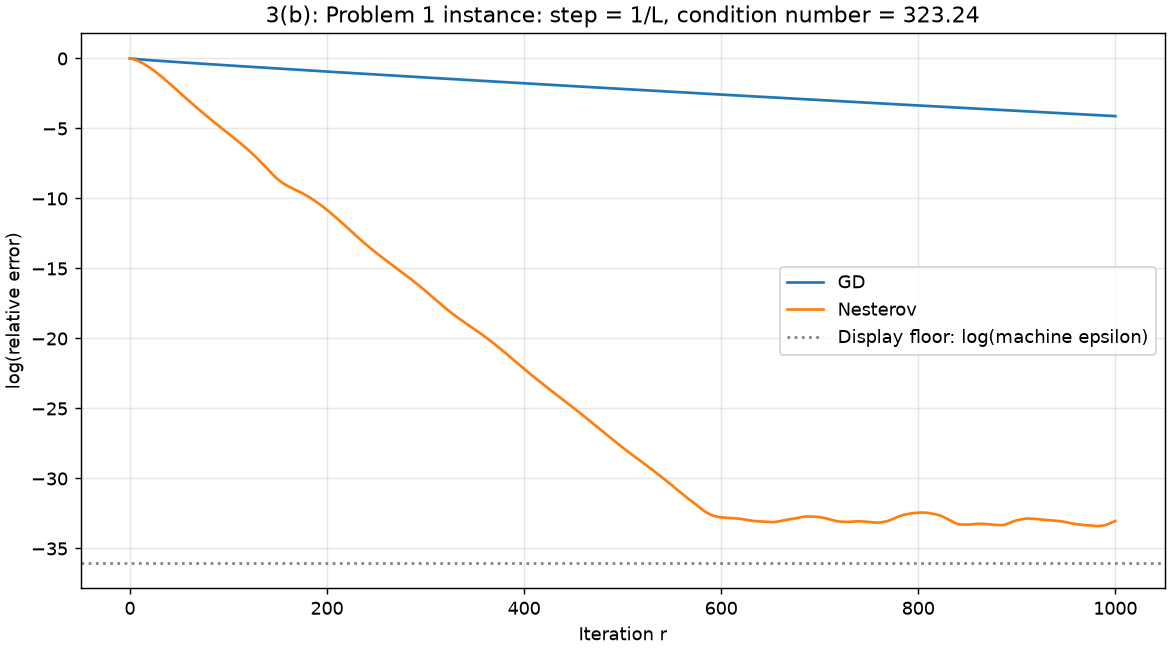

In [26]:
data_3b = plot_problem3_convergence(Q_3a, b_3a, "3(b): Problem 1 instance")

**Reading the 3(b) plot:** Nesterov reaches errors near numerical precision much earlier than GD. The flattening and tiny fluctuations at the bottom reflect floating-point effects.

## 3(c): Increase the step size and report convergence ranges

Keep the same instance from 3(a). Sweep $\alpha=c/L$ from $c=0.10$ to $2.20$ in increments of $0.01$, using 1000 updates per run. The increment and iteration budget are our experimental choices.

**Momentum convention:** Keep Nesterov's $\gamma=(\sqrt{L/\mu}-1)/(\sqrt{L/\mu}+1)$ fixed while varying only the gradient step. This isolates step-size sensitivity. Changing the momentum using an estimated $L$ would be a different experiment; the assignment does not specify such a change.

**Why use a stability check as well as numerical runs?** Reaching a selected tolerance within 1000 steps is not the same as converging as $r\to\infty$. For this quadratic, we can analyze the linear error updates exactly in each eigenvector direction.

**Our derivation, using the updates from 1(c–d):** Write $a=1-\alpha\lambda$, where $\lambda$ is an eigenvalue of $Q$.

- GD multiplies that component of the error by $a$. All components decay precisely when $|a|<1$ for every eigenvalue, giving $0<\alpha<2/L$.
- Nesterov's gradient-step error obeys $u_{r+1}=a[(1+\gamma)u_r-\gamma u_{r-1}]$. Its characteristic roots solve
$$z^2-(1+\gamma)az+\gamma a=0.$$
All roots must have modulus less than 1 for asymptotic stability. The quadratic unit-disk conditions are $1-a>0$, $1+(1+2\gamma)a>0$, and $1-\gamma a>0$. With $0\leq\gamma<1$ and positive step sizes, these give
$$0<\alpha<\frac{2(1+\gamma)}{(1+2\gamma)L}.$$
The upper boundary has a root of modulus 1 and is excluded. These are stability guarantees for arbitrary initial errors in exact arithmetic, not claims based solely on one finite trajectory.

`stability_radius` computes the largest root modulus over all eigenvalues (the spectral radius). We label a step stable when this is below 1. The sweep also records actual relative errors after 1000 updates; its printed stable range is limited to the tested 0.01 grid.

In [27]:
def stability_radius(eigenvalues, step, method, gamma=0.0):
    a = 1 - step * eigenvalues
    if method == "GD":
        return np.max(np.abs(a))
    if method != "Nesterov":
        raise ValueError("method must be GD or Nesterov")
    linear = (1 + gamma) * a
    discriminant = linear**2 - 4 * gamma * a
    root_delta = np.sqrt(discriminant.astype(complex))
    root_plus = (linear + root_delta) / 2
    root_minus = (linear - root_delta) / 2
    return max(np.max(np.abs(root_plus)), np.max(np.abs(root_minus)))


def sweep_problem3_steps(Q_case, b_case, data, label):
    step_multipliers = np.arange(10, 221) / 100
    L_case, gamma_case = data["L"], data["gamma"]
    rows = []
    for method in ("GD", "Nesterov"):
        for c in step_multipliers:
            step = c / L_case
            radius = stability_radius(data["eigenvalues"], step, method, gamma_case)
            errors = convergence_history(
                Q_case, b_case, np.zeros(len(b_case)), data["x_star"],
                1000, step, method, gamma_case
            )
            rows.append({"method": method, "c": c, "radius": radius,
                         "stable": radius < 1 - 1e-12, "error_1000": errors[-1]})

    print(f"\n{label}: L = {L_case:.6f}, gamma = {gamma_case:.6f}")
    for method in ("GD", "Nesterov"):
        upper_c = 2.0 if method == "GD" else 2 * (1 + gamma_case) / (1 + 2 * gamma_case)
        stable_cs = [row["c"] for row in rows if row["method"] == method and row["stable"]]
        print(f"{method}: exact stability range 0 < alpha < {upper_c:.6f}/L")
        print(f"  Within requested interval: 0.1/L <= alpha < {upper_c:.6f}/L")
        print(f"  Stable tested grid: {min(stable_cs):.2f}/L through {max(stable_cs):.2f}/L")
    print(f"{'Method':<12} {'c = alpha*L':>14} {'Radius':>12} {'Stable':>9} {'Error at 1000':>17}")
    for row in rows:
        # Compact output around the nominal step and the stability boundaries.
        if np.any(np.isclose(row["c"], [0.1, 1.0, 1.35, 1.36, 1.37, 1.99, 2.0, 2.2])):
            print(f"{row['method']:<12} {row['c']:>14.2f} {row['radius']:>12.6f} "
                  f"{str(row['stable']):>9} {row['error_1000']:>17.6e}")
    return rows

In [28]:
sweep_3c = sweep_problem3_steps(Q_3a, b_3a, data_3b, "3(c): Problem 1 instance")


3(c): Problem 1 instance: L = 376.266204, gamma = 0.894620
GD: exact stability range 0 < alpha < 2.000000/L
  Within requested interval: 0.1/L <= alpha < 2.000000/L
  Stable tested grid: 0.10/L through 1.99/L
Nesterov: exact stability range 0 < alpha < 1.358521/L
  Within requested interval: 0.1/L <= alpha < 1.358521/L
  Stable tested grid: 0.10/L through 1.35/L
Method          c = alpha*L       Radius    Stable     Error at 1000
GD                     0.10     0.999691      True      6.101476e-01
GD                     1.00     0.996906      True      1.629151e-02
GD                     1.35     0.995824      True      4.451992e-03
GD                     1.36     0.995793      True      4.292256e-03
GD                     1.37     0.995762      True      4.138355e-03
GD                     1.99     0.993844      True      4.473384e-04
GD                     2.00     1.000000     False      4.781329e-04
GD                     2.20     1.200000     False               inf
Nesterov     

**Answer to 3(c):** Within the requested interval, GD is stable for $0.1/L\leq\alpha<2/L$, while fixed-momentum Nesterov is stable for $0.1/L\leq\alpha<1.358521/L$ on this instance. GD therefore tolerates larger steps and is more robust to underestimating $L$. The upper endpoints are excluded. Overestimating $L$ gives smaller steps, which remain stable in the tested range but can slow progress.

The stable sampled steps end at $1.99/L$ for GD and $1.35/L$ for Nesterov. The mathematical stability check gives a sharper boundary than the grid. In particular, a small error after 1000 iterations alone does not establish asymptotic convergence.

## 3(d): Repeat (a), (b), and (c) for one instance of Problem 2

Now change the generator to use $D=\operatorname{diag}(\log(10+e^z))$. Use the same seed `652` in a separate generator to hold $B$, the underlying normal draws, and $b$ fixed across the two problem types. Recompute the reference solution and curvature parameters for the new matrix, then repeat the plot and step-size sweep.

### Generate the Problem 2 instance

In [29]:
Q_3d, b_3d = generate_problem2(np.random.default_rng(652))
print("Q shape:", Q_3d.shape)
print("b shape:", b_3d.shape)

Q shape: (100, 100)
b shape: (100,)


### Plot convergence for the Problem 2 instance

Use the same zero start, nominal step $1/L$, and 1000 iterations as in 3(b).

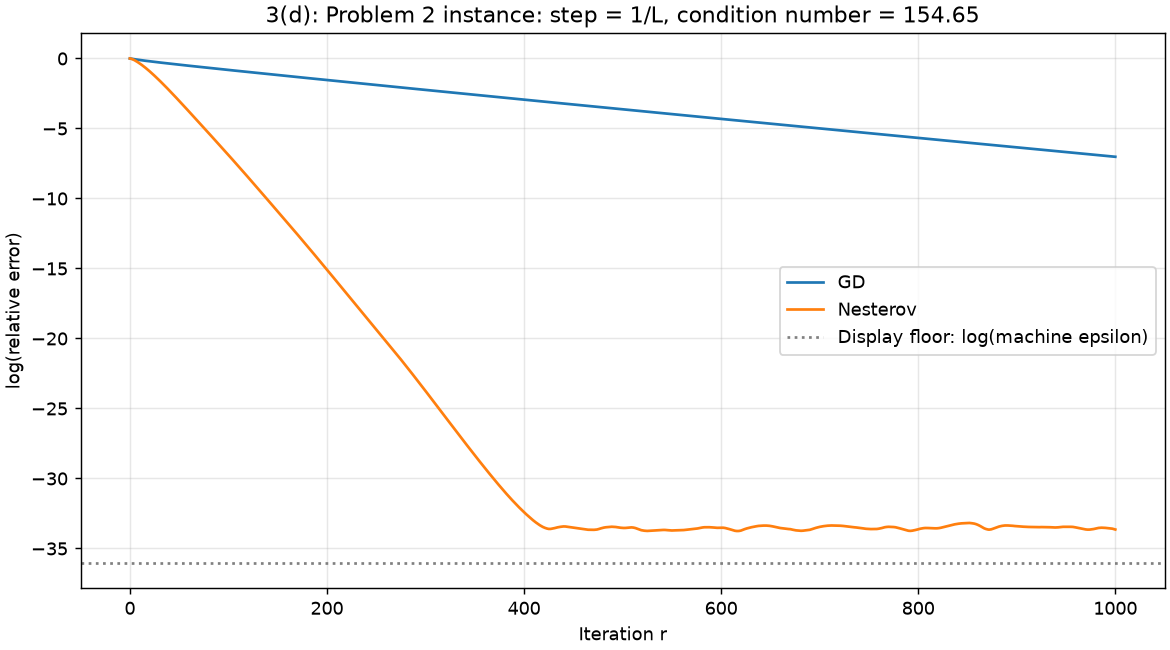

In [30]:
data_3d = plot_problem3_convergence(Q_3d, b_3d, "3(d): Problem 2 instance")

### Sweep the step size for the Problem 2 instance

Repeat the experiment from 3(c), with this instance's own $L$ and fixed momentum coefficient.

In [31]:
sweep_3d = sweep_problem3_steps(Q_3d, b_3d, data_3d, "3(d): Problem 2 instance")


3(d): Problem 2 instance: L = 376.981523, gamma = 0.851143
GD: exact stability range 0 < alpha < 2.000000/L
  Within requested interval: 0.1/L <= alpha < 2.000000/L
  Stable tested grid: 0.10/L through 1.99/L
Nesterov: exact stability range 0 < alpha < 1.370057/L
  Within requested interval: 0.1/L <= alpha < 1.370057/L
  Stable tested grid: 0.10/L through 1.37/L
Method          c = alpha*L       Radius    Stable     Error at 1000
GD                     0.10     0.999353      True      4.423213e-01
GD                     1.00     0.993534      True      8.927615e-04
GD                     1.35     0.991270      True      8.518876e-05
GD                     1.36     0.991206      True      7.967191e-05
GD                     1.37     0.991141      True      7.451287e-05
GD                     1.99     0.990000      True      1.184133e-06
GD                     2.00     1.000000     False      2.922245e-04
GD                     2.20     1.200000     False               inf
Nesterov     

**Answer to 3(d):** Within the requested interval, GD is stable for $0.1/L\leq\alpha<2/L$ and fixed-momentum Nesterov for $0.1/L\leq\alpha<1.370057/L$. The stable sampled steps end at $1.99/L$ and $1.37/L$, respectively.

The Problem 2 instance has a smaller condition number (about 154.65 versus 323.24). At the nominal step, the plot shows faster progress than for the Problem 1 instance. GD still has the wider stability interval, so the conclusion about robustness to oversized steps is unchanged.

# Problem 4: Effect of restart in accelerated Nesterov

**Source:** [Homework_2.pdf](../Homework_2.pdf), page 3, Problem 4(a–c). Follow the assignment order: generate one instance, compare the four specified methods in a convergence plot, and report the findings.

## 4(a): Generate one instance of Problem 2

Use the Problem 2 generator, with $D=\operatorname{diag}(\log(10+e^z))$. Seed `653` is our reproducibility choice. Compute the reference solution, the curvature parameters, and $\kappa=L/\mu$ for this instance. The condition-number formula comes from Lecture 7, slide 1/5 (PDF page 2), as used in 1(h).

In [32]:
Q_4, b_4 = generate_problem2(np.random.default_rng(653))
x0_4 = np.zeros(len(b_4))
x_star_4 = np.linalg.solve(Q_4, -b_4)
eigenvalues_4 = np.linalg.eigvalsh(Q_4)
mu_4 = eigenvalues_4.min()
L_4 = eigenvalues_4.max()
kappa_4 = L_4 / mu_4

print(f"Q shape: {Q_4.shape}; b shape: {b_4.shape}")
print(f"mu = {mu_4:.6f}; L = {L_4:.6f}")
print(f"kappa = {kappa_4:.6f}; sqrt(kappa) = {np.sqrt(kappa_4):.6f}")
print(f"Gradient norm at reference solution: {np.linalg.norm(grad_f(x_star_4, Q_4, b_4)):.6e}")

Q shape: (100, 100); b shape: (100,)
mu = 2.431906; L = 426.867181
kappa = 175.527811; sqrt(kappa) = 13.248691
Gradient norm at reference solution: 4.116466e-13


## 4(b): Plot Nesterov with and without periodic restart

Compare exactly the four variants requested: no restart and restart periods $\sqrt{\kappa}$, $5\sqrt{\kappa}$, and $20\sqrt{\kappa}$. All four use the same instance, zero starting point, step $1/L$, fixed momentum coefficient from 1(d), and a budget of 1000 iterations.

**Method source:** Bubeck, [Section 3.7.1](../textbook%20and%20materials/1405.4980v2.pdf), printed page 290 (PDF page 63), gives the strongly convex Nesterov update used throughout this notebook:
$$y_{r+1}=x_r-\frac1L(Qx_r+b),\qquad x_{r+1}=y_{r+1}+\gamma(y_{r+1}-y_r).$$

**Restart implementation:** At the end of every $T$ updates, set `x = y.copy()`. This discards the extrapolation and begins the next block at the current gradient-step estimate with both sequences equal. The next step is therefore an ordinary gradient step before momentum builds again. We keep $Q,b,L,\mu$, and $\gamma$ fixed; restart does not return to the original zero vector or regenerate the problem. The periods come from the homework; this explicit reset is our implementation of restarting the algorithm at its current estimate.

**Integer periods:** Use $T=\lceil c\sqrt{\kappa}\rceil$ for $c=1,5,20$. The assignment does not specify rounding, so we round each complete expression up to the next integer. Count completed updates with `r + 1`; restarting after the $T$-th update affects the following update.

Record the gradient-step sequence `y`, consistently with 1(d) and Problem 3. The plot uses natural-log relative error, with the same display-only machine-epsilon floor as Problem 3.

In [33]:
def nesterov_restart_history(Q, b, x0, x_star, num_iters, restart_every=None):
    if restart_every is not None and (
        not isinstance(restart_every, (int, np.integer)) or restart_every < 1
    ):
        raise ValueError("restart_every must be a positive integer or None.")

    eigenvalues = np.linalg.eigvalsh(Q)
    mu, L = eigenvalues.min(), eigenvalues.max()
    kappa = L / mu
    gamma = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)
    x = np.array(x0, dtype=float, copy=True)
    y = x.copy()
    initial_distance = np.linalg.norm(x0 - x_star)
    if initial_distance == 0:
        raise ValueError("Relative error requires x0 different from x_star.")
    errors = [1.0]

    for r in range(num_iters):
        y_next = x - grad_f(x, Q, b) / L
        x_next = y_next + gamma * (y_next - y)
        y, x = y_next, x_next

        if restart_every is not None and (r + 1) % restart_every == 0:
            x = y.copy()  # Restart from the current estimate with no extrapolation.

        errors.append(np.linalg.norm(y - x_star) / initial_distance)

    return np.array(errors)

No restart: none
T = ceil(sqrt(kappa)): 14
T = ceil(5 sqrt(kappa)): 67
T = ceil(20 sqrt(kappa)): 265


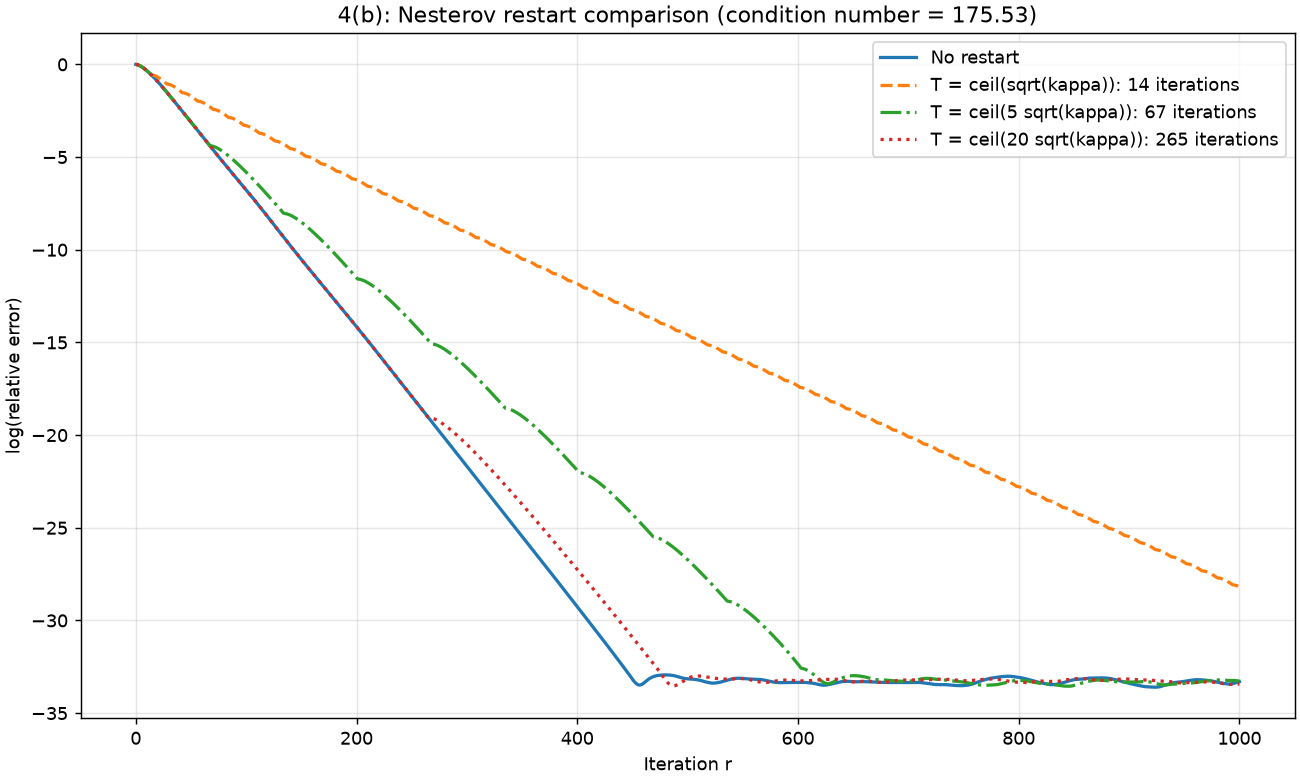

In [34]:
restart_periods_4 = {
    "No restart": None,
    "T = ceil(sqrt(kappa))": int(np.ceil(np.sqrt(kappa_4))),
    "T = ceil(5 sqrt(kappa))": int(np.ceil(5 * np.sqrt(kappa_4))),
    "T = ceil(20 sqrt(kappa))": int(np.ceil(20 * np.sqrt(kappa_4))),
}
num_iters_4 = 1000
histories_4 = {}
for label, period in restart_periods_4.items():
    histories_4[label] = nesterov_restart_history(
        Q_4, b_4, x0_4, x_star_4, num_iters_4, restart_every=period
    )
    print(f"{label}: {period if period is not None else 'none'}")

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
styles_4 = ["-", "--", "-.", ":"]
for (label, errors), style in zip(histories_4.items(), styles_4):
    period = restart_periods_4[label]
    legend_label = label if period is None else f"{label}: {period} iterations"
    ax.plot(np.arange(num_iters_4 + 1),
            np.log(np.maximum(errors, np.finfo(float).eps)),
            linestyle=style, linewidth=1.8, label=legend_label)
ax.set(xlabel="Iteration r", ylabel="log(relative error)",
       title=f"4(b): Nesterov restart comparison (condition number = {kappa_4:.2f})")
ax.grid(alpha=0.3)
ax.legend()
plt.show()
plt.close(fig)

## 4(c): Findings

To make the plot's speed differences easier to describe, the table below reports the first iteration at which each method reaches relative error $10^{-8}$. This threshold is our descriptive choice, not an additional homework convergence requirement; all methods still run for 1000 iterations.

In [35]:
threshold_4 = 1e-8
first_hits_4 = {}
print(f"{'Method':<28} {'First error <= 1e-8':>22} {'Final relative error':>23}")
for label, errors in histories_4.items():
    hits = np.flatnonzero(errors <= threshold_4)
    first_hit = int(hits[0]) if len(hits) else None
    first_hits_4[label] = first_hit
    hit_text = str(first_hit) if first_hit is not None else "not reached"
    print(f"{label:<28} {hit_text:>22} {errors[-1]:>23.6e}")

Method                          First error <= 1e-8    Final relative error
No restart                                      257            3.449221e-15
T = ceil(sqrt(kappa))                           641            5.788631e-13
T = ceil(5 sqrt(kappa))                         333            3.566171e-15
T = ceil(20 sqrt(kappa))                        257            3.006148e-15


On this instance, no restart reaches relative error $10^{-8}$ in 257 iterations, while restarting every 14 and 67 iterations takes 641 and 333 iterations, respectively. Restarting every 265 iterations also reaches the threshold in 257 iterations, before its first restart, so it matches the no-restart curve up to that point. Frequent restarts discard useful momentum and slow progress for this strongly convex Nesterov method with its curvature-based momentum coefficient. All four methods attain small final errors, and differences near floating-point precision do not show a meaningful accuracy advantage; restart is not automatically beneficial for this instance and parameter choice.